# Experiment 5.4 — SNN-native causal WHAT–WHEN fusion

Analysis-only notebook for the finalized `snn_native_what_when_fusion_v1` artifacts. The primary question is whether aligned frozen WHEN spikes improve final letter classification beyond WHAT-only, elapsed-time, reset-WHEN, and parameter-matched linear fusion.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "notebooks").is_dir():
    repo_root = repo_root.parent
root = repo_root / "notebooks" / "artifacts" / "experiment_5_4_snn_native_fusion" / "snn_native_what_when_fusion_v1"

runs = pd.read_csv(root / "runs.csv")
histories = pd.read_csv(root / "histories.csv")
ablations = pd.read_csv(root / "ablation_runs.csv")
activity = pd.read_csv(root / "activity_runs.csv")
paired = pd.read_csv(root / "paired_deltas.csv")
manifest = json.loads((root / "manifest.json").read_text(encoding="utf-8"))
manifest


{'aggregation_policy': 'finalizer aggregates existing 30 run artifacts only; it never trains or regenerates caches',
 'architecture_contract': 'frozen WHAT128 spikes + frozen context64 -> fixed W_what/W_when -> short-memory non-recurrent Fusion128 -> fixed W_out -> per-timestep 12D evidence -> non-leaky whole-sequence accumulator',
 'causality_contract': 'elapsed baseline uses absolute t/fs only; final duration is not an input to any condition; valid length only masks padded updates and selects the endpoint',
 'conditions': ['what_only_lif',
  'when_only_lif',
  'what_elapsed_lif',
  'what_resetwhen_lif',
  'what_when_linear',
  'what_when_fusion_lif'],
 'expected_train_runs': 30,
 'experiment_id': 'experiment_5_4_snn_native_fusion',
 'files': {'ablation_runs': 'ablation_runs.csv',
  'activity_runs': 'activity_runs.csv',
  'histories': 'histories.csv',
  'paired_deltas': 'paired_deltas.csv',
  'runs': 'runs.csv'},
 'fusion_recurrent': False,
 'fusion_short_shift': 1,
 'fusion_width': 1

## Primary architecture comparison

The primary metric is test balanced accuracy. Report mean and standard deviation over the five paired seeds.


In [2]:
summary = (
    runs.groupby(["condition", "fusion_mode"], as_index=False)
    .agg(
        test_ba_mean=("test_balanced_accuracy", "mean"),
        test_ba_sd=("test_balanced_accuracy", "std"),
        test_macro_f1_mean=("test_macro_f1", "mean"),
        val_ba_mean=("val_balanced_accuracy", "mean"),
        train_ba_mean=("train_balanced_accuracy", "mean"),
        params=("parameter_count", "first"),
    )
    .sort_values("test_ba_mean", ascending=False)
)
summary


,condition,fusion_mode,test_ba_mean,test_ba_sd,test_macro_f1_mean,val_ba_mean,train_ba_mean,params
4,what_when_linear,linear,0.482160,0.034045,0.475770,0.517561,0.945614,26124
3,what_when_fusion_lif,lif,0.479026,0.041554,0.472260,0.459278,0.977408,26124
0,what_elapsed_lif,lif,0.476692,0.048168,0.468565,0.539816,1.000000,26124
2,what_resetwhen_lif,lif,0.474518,0.050532,0.467307,0.506461,0.989416,26124
1,what_only_lif,lif,0.472231,0.056130,0.467314,0.494636,0.972129,26124
5,when_only_lif,lif,0.386768,0.050615,0.385122,0.399329,0.916119,26124


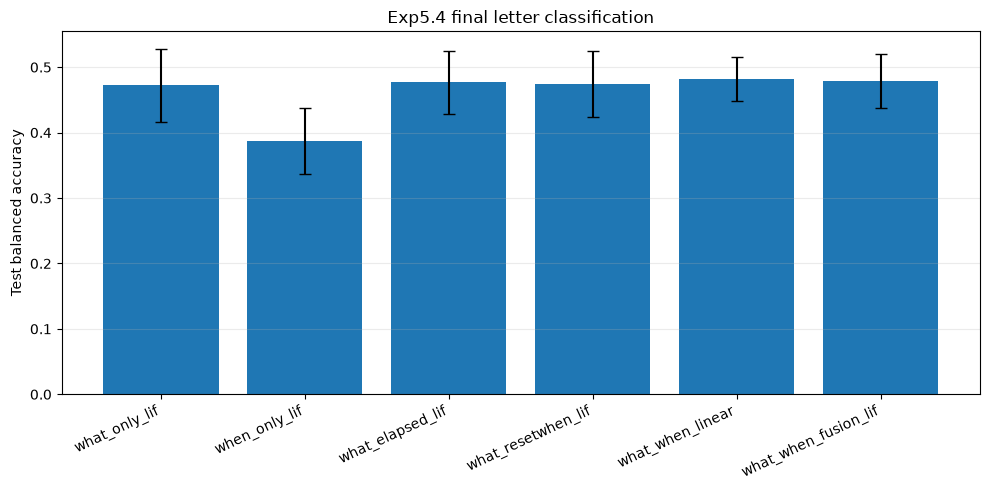

In [3]:
order = manifest["conditions"]
plot_df = summary.set_index("condition").loc[order].reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
ax.bar(x, plot_df["test_ba_mean"], yerr=plot_df["test_ba_sd"], capsize=4)
ax.set_xticks(x, plot_df["condition"], rotation=25, ha="right")
ax.set_ylabel("Test balanced accuracy")
ax.set_title("Exp5.4 final letter classification")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()


## Paired deltas from the primary Fusion-LIF model

Positive `delta_test_balanced_accuracy` means `what_when_fusion_lif` beats the named control on the same seed.


In [4]:
paired_summary = (
    paired.groupby("comparator", as_index=False)
    .agg(
        delta_ba_mean=("delta_test_balanced_accuracy", "mean"),
        delta_ba_sd=("delta_test_balanced_accuracy", "std"),
        wins=("delta_test_balanced_accuracy", lambda x: int((x > 0).sum())),
        delta_macro_f1_mean=("delta_test_macro_f1", "mean"),
    )
    .sort_values("delta_ba_mean", ascending=False)
)
paired_summary


,comparator,delta_ba_mean,delta_ba_sd,wins,delta_macro_f1_mean
4,when_only_lif,0.092259,0.058822,4,0.087138
1,what_only_lif,0.006795,0.016415,4,0.004946
2,what_resetwhen_lif,0.004508,0.029118,2,0.004953
0,what_elapsed_lif,0.002334,0.024124,2,0.003695
3,what_when_linear,-0.003133,0.034018,2,-0.003510


## WHEN alignment attribution

The trained primary checkpoint is evaluated with aligned WHEN, WHEN zeroed, valid timesteps shuffled, and a circular temporal shift. This distinguishes generic spike statistics from correct WHAT/WHEN temporal alignment.


In [5]:
ablation_summary = (
    ablations.groupby("ablation", as_index=False)
    .agg(
        test_ba_mean=("test_balanced_accuracy", "mean"),
        test_ba_sd=("test_balanced_accuracy", "std"),
        test_macro_f1_mean=("test_macro_f1", "mean"),
        fusion_fr_mean=("fusion_firing_fraction", "mean"),
    )
    .sort_values("test_ba_mean", ascending=False)
)
ablation_summary


,ablation,test_ba_mean,test_ba_sd,test_macro_f1_mean,fusion_fr_mean
0,ordered,0.479026,0.041554,0.472260,0.224824
2,when_shuffle,0.438465,0.026032,0.429217,0.245443
1,when_circular_shift,0.425767,0.028737,0.420161,0.261285
3,when_zero,0.306398,0.085655,0.269291,0.178964


In [6]:
ordered = ablations[ablations["ablation"] == "ordered"].set_index("seed")
alignment_rows = []
for name in ("when_zero", "when_shuffle", "when_circular_shift"):
    control = (
        ablations[ablations["ablation"] == name]
        .groupby("seed", as_index=True)["test_balanced_accuracy"].mean()
    )
    delta = ordered["test_balanced_accuracy"] - control
    alignment_rows.append({
        "ablation": name,
        "aligned_minus_ablation_ba_mean": delta.mean(),
        "aligned_minus_ablation_ba_sd": delta.std(),
        "aligned_wins": int((delta > 0).sum()),
    })
pd.DataFrame(alignment_rows)


,ablation,aligned_minus_ablation_ba_mean,aligned_minus_ablation_ba_sd,aligned_wins
0,when_zero,0.172628,0.095702,5
1,when_shuffle,0.040561,0.042222,4
2,when_circular_shift,0.053259,0.014004,5


## Generalization and Fusion activity

A large train–test gap would indicate that the Fusion head is fitting user-specific trajectories rather than extracting transferable WHAT×WHEN structure. Fusion firing fraction is only defined for LIF conditions; the linear control has no Fusion spikes.


In [7]:
generalization = runs.assign(
    train_test_gap=runs["train_balanced_accuracy"] - runs["test_balanced_accuracy"]
).groupby("condition", as_index=False).agg(
    train_ba=("train_balanced_accuracy", "mean"),
    val_ba=("val_balanced_accuracy", "mean"),
    test_ba=("test_balanced_accuracy", "mean"),
    train_test_gap=("train_test_gap", "mean"),
)
generalization


,condition,train_ba,val_ba,test_ba,train_test_gap
0,what_elapsed_lif,1.000000,0.539816,0.476692,0.523308
1,what_only_lif,0.972129,0.494636,0.472231,0.499898
2,what_resetwhen_lif,0.989416,0.506461,0.474518,0.514898
3,what_when_fusion_lif,0.977408,0.459278,0.479026,0.498382
4,what_when_linear,0.945614,0.517561,0.482160,0.463454
5,when_only_lif,0.916119,0.399329,0.386768,0.529352


In [8]:
activity_test = activity[activity["split"] == "test"]
activity_test.groupby("condition", as_index=False).agg(
    fusion_firing_fraction_mean=("fusion_firing_fraction", "mean"),
    fusion_firing_fraction_sd=("fusion_firing_fraction", "std"),
)


,condition,fusion_firing_fraction_mean,fusion_firing_fraction_sd
0,what_elapsed_lif,0.186029,0.015115
1,what_only_lif,0.168728,0.020016
2,what_resetwhen_lif,0.174388,0.015979
3,what_when_fusion_lif,0.224824,0.028327
4,what_when_linear,NaN,NaN
5,when_only_lif,0.211777,0.025665


## Interpretation checklist

The strongest support for the SNN-native fusion hypothesis requires: (1) main > WHAT-only; (2) main > elapsed-time; (3) main > reset-WHEN; (4) main > parameter-matched linear fusion; and (5) aligned WHEN > zero/shuffle/circular-shift ablations. `when_only_lif` is a leakage/identity diagnostic rather than a desired winner.
